### Prepared by: 
Yuting Chen 259430, 
Kacper Miklaszewski 243215, 
Jakub Szlarzyński 241004

In [35]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

## 1,Data spliting

In [36]:
#load dataset
df = pd.read_csv("data_clean/S2_cleaned_data.csv")

In [43]:
# a) Define target and features
target_col = "Sleep_Quality"
# Problem formulation:
y = df[target_col].apply(lambda x: 0 if x <= 5 else 1)
# Remove target and ID to prevent leakage
X = df.drop(columns=[target_col, "Student_ID"], errors="ignore")
# Explicit leakage check
assert target_col not in X.columns, "Data leakage detected: target in features!"
# Check class balance (once, clean, academic)
print("========= Target class distribution =========")
print(y.value_counts(normalize=True).round(3))

# b) Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# c) Encode categorical features
# Gender (nominal)
gender_encoder = LabelEncoder()
X_train["Gender"] = gender_encoder.fit_transform(X_train["Gender"])
X_test["Gender"] = gender_encoder.transform(X_test["Gender"])
# University_Year (ordinal)
year_encoder = OrdinalEncoder(
    categories=[["1st year", "2nd year", "3rd year", "4th year"]]
)
X_train["University_Year"] = year_encoder.fit_transform(
    X_train[["University_Year"]]
)
X_test["University_Year"] = year_encoder.transform(
    X_test[["University_Year"]]
)

========= Target class distribution =========
Sleep_Quality
0    0.506
1    0.494
Name: proportion, dtype: float64


## 2, Build & Train & Evaluate the model

In [38]:
# load processed splits
X_train = pd.read_csv("data_splits/X_train.csv")
X_test  = pd.read_csv("data_splits/X_test.csv")
y_train = pd.read_csv("data_splits/y_train.csv").squeeze()
y_test  = pd.read_csv("data_splits/y_test.csv").squeeze()

### 2.1 Decision Tree

============= Decision Tree Evaluation Metrics =============
Confusion Matrix:
 [[31 24]
 [24 21]]
Precision: 0.4666666666666667
Recall: 0.4666666666666667
F1-score: 0.4666666666666667
Accuracy: 0.52
AUC: 0.5290909090909091


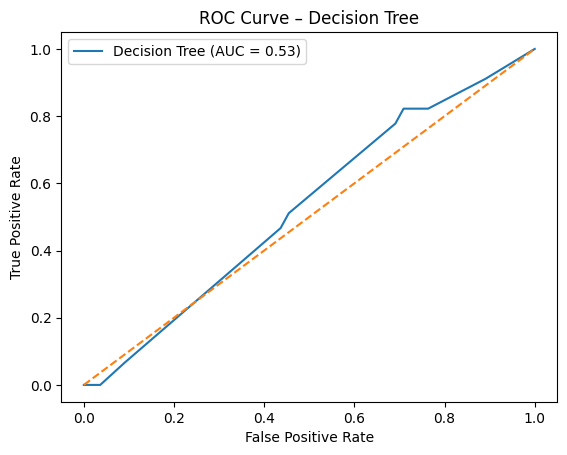

Cross-validation F1 scores: [0.63461538 0.60273973 0.55319149 0.41025641 0.5       ]
Mean CV F1: 0.5401606020521788
Std CV F1: 0.07936703312326475


In [39]:
#Decision Tree
#a Initialize & train Decision Tree model
dt = DecisionTreeClassifier(
    max_depth=5,          # prevent overfitting
    random_state=42,
    class_weight="balanced"
)

dt.fit(X_train, y_train)

#b Predictions
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]

#c Evaluation metrics
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("============= Decision Tree Evaluation Metrics =============")
print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Accuracy:", accuracy)
print("AUC:", auc)

#d Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Decision Tree")
plt.legend()
plt.show()

#e Cross-validation
cv_scores = cross_val_score(
    dt,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())
print("Std CV F1:", cv_scores.std())

### 2.2 Random Forest

============= Random Forest Evaluation Metrics =============
Confusion Matrix:
 [[25 30]
 [28 17]]
Precision: 0.3617021276595745
Recall: 0.37777777777777777
F1-score: 0.3695652173913043
Accuracy: 0.42
AUC: 0.4290909090909091


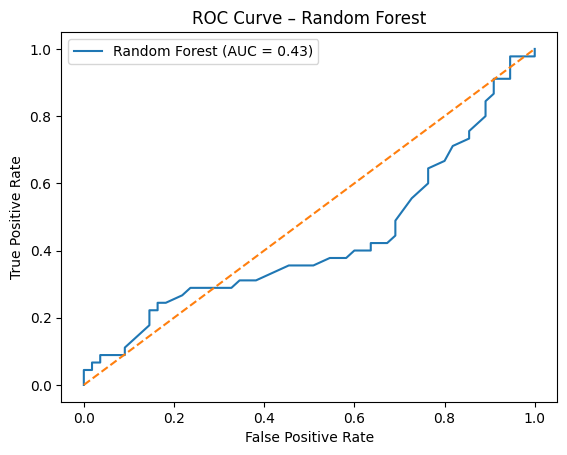

Cross-validation F1 scores: [0.60674157 0.52631579 0.46153846 0.5        0.47619048]
Mean CV F1: 0.514157260047266
Std CV F1: 0.05124515097834874


In [40]:
#random forest
#a Initialize & train the Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"   # helps with class imbalance
)

rf.fit(X_train, y_train)

#b predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

#c Evaluation metrics
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("============= Random Forest Evaluation Metrics =============")
print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Accuracy:", accuracy)
print("AUC:", auc)

#d Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.show()

#e Cross-validation
cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())
print("Std CV F1:", cv_scores.std())

### 2.3 KNN


============= KNN Evaluation Metrics =============
Confusion Matrix:
 [[20 35]
 [19 26]]
Precision: 0.4262295081967213
Recall: 0.5777777777777777
F1-score: 0.49056603773584906
Accuracy: 0.46
AUC: 0.5048484848484849


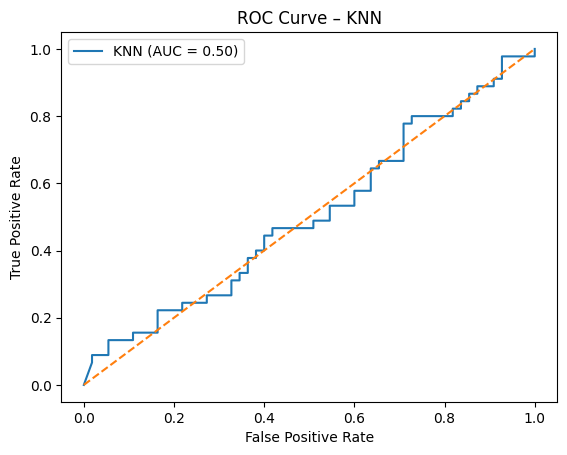

Cross-validation F1 scores: [0.58333333 0.58823529 0.58536585 0.51764706 0.49315068]
Mean CV F1: 0.5535464449729106
Std CV F1: 0.04009853737773154


In [41]:
#KNN
#a Scale the features (KNN is distance-based)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#b Initialize and train the KNN model
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"   # helps when classes are imbalanced
)

knn.fit(X_train_scaled, y_train)

#c predictions
y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)[:, 1]

#d Evaluation metrics
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("============= KNN Evaluation Metrics =============")
print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Accuracy:", accuracy)
print("AUC:", auc)

#e Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN")
plt.legend()
plt.show()

#f Cross-validation
cv_scores = cross_val_score(
    knn,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())
print("Std CV F1:", cv_scores.std())

### 2.4 SVM

============= SVM Evaluation Metrics =============
Confusion Matrix:
 [[30 25]
 [23 22]]
Precision: 0.46808510638297873
Recall: 0.4888888888888889
F1-score: 0.4782608695652174
Accuracy: 0.52
AUC: 0.48


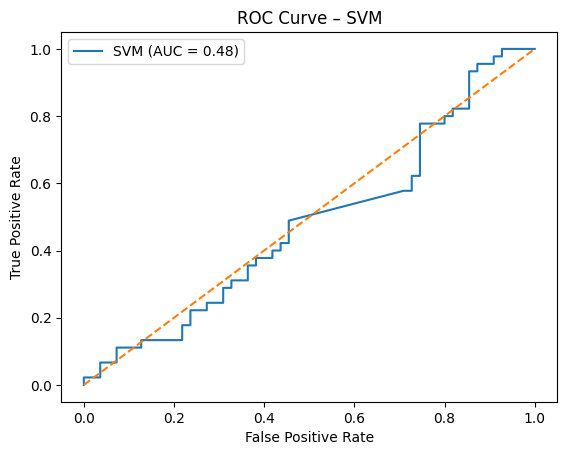

Cross-validation F1 scores: [0.61052632 0.52380952 0.53846154 0.525      0.35294118]
Mean CV F1: 0.5101477109062248
Std CV F1: 0.08485124305693138


In [42]:
#SVM
#a Scale the features (SVM is scale-sensitive)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#b Initialize & train the SVM model
svm = SVC(
    kernel="rbf",        
    probability=True,    
    class_weight="balanced"  
)

svm.fit(X_train_scaled, y_train)

#c Predictions
y_pred = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]

#d Evaluation metrics
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("============= SVM Evaluation Metrics =============")
print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Accuracy:", accuracy)
print("AUC:", auc)

#e Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SVM")
plt.legend()
plt.show()

#f Cross-validation 
cv_scores = cross_val_score(
    svm,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())
print("Std CV F1:", cv_scores.std())

## 3, Report

#### 3.1 Model Comparison
Four classification models were evaluated: Decision Tree, Random Forest, kNN, and SVM.
The Decision Tree achieved an accuracy of 0.52 and an F1-score of approximately 0.47, indicating limited predictive performance.
Random Forest showed the weakest performance among the evaluated models, with an accuracy of 0.42 and an F1-score of approximately 0.37, and did not outperform the Decision Tree.
The kNN model achieved the highest test F1-score (0.49) and showed a better balance between precision and recall.
The SVM model reached an accuracy of 0.52 and an F1-score of approximately 0.48, but its performance was less consistent.

#### 3.2 Metric Interpretation
Multiple metrics were used to evaluate the models, including accuracy, precision, recall, F1-score, and AUC.
F1-score was emphasized because it balances precision and recall and is suitable for classification tasks.
Most models achieved AUC values close to 0.50, indicating limited ability to separate the two classes.
Accuracy alone was not sufficient to evaluate performance, as it does not reflect the balance between false positives and false negatives.

#### 3.3 Cross-Validation and Stability
Cross-validation was applied to assess model stability.
The kNN model achieved the highest mean cross-validation F1-score (approximately 0.55) with the lowest standard deviation, indicating stable performance.
Decision Tree and SVM showed larger variation across folds, while Random Forest had consistently low but stable results.

#### 3.4 Challenges and Observations
Overall model performance was moderate, suggesting weak relationships between features and the target variable.
Some models showed sensitivity across cross-validation folds, which affected their stability.
In addition, default model parameters may have limited the performance of more complex models such as Random Forest.

#### 3.5 Final Model Selection
Based on test performance and cross-validation results, kNN was selected as the final model.
Although overall performance was not high, kNN showed the best balance between performance and stability and therefore meets the requirements of this task.